# Лабораторная работа №4
## Линейные модели, SVM и деревья решений.

### Выполнил студент группы РТ5-61Б Иванов А.А.

**Цель лабораторной работы**: изучение линейных моделей, SVM и деревьев решений.

Dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report
)


In [2]:
data = pd.read_csv("heart.csv", sep=",")

In [3]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [5]:
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [6]:
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

In [7]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

pipeline_lr.fit(X_train, y_train)

y_pred = pipeline_lr.predict(X_test)

print("=== Логистическая регрессия ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



=== Логистическая регрессия ===

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [24]:
pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(class_weight='balanced', random_state=42))
])

pipeline_svm.fit(X_train, y_train)

y_pred = pipeline_svm.predict(X_test)

print("=== SVM ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== SVM ===

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [11]:
pipeline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

pipeline_tree.fit(X_train, y_train)

y_pred = pipeline_tree.predict(X_test)

print("=== DecisionTreeClassifier ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== DecisionTreeClassifier ===

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        82
           1       0.81      0.81      0.81       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184



In [12]:
param_grid = {
    'classifier__max_depth': [None, 3, 5, 7, 10],            # Глубина дерева
    'classifier__min_samples_split': [2, 5, 10, 20],         # Мин. сэмплов для разделения узла
    'classifier__min_samples_leaf': [1, 5, 10, 15],          # Мин. сэмплов в листе
    'classifier__criterion': ['gini', 'entropy']             # Критерий качества ветвления
}

grid_search = GridSearchCV(
    pipeline_tree, 
    param_grid,  
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_test_pred_best=best_model.predict(X_test)

Best params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 15, 'classifier__min_samples_split': 2}
Best CV score: 0.8613


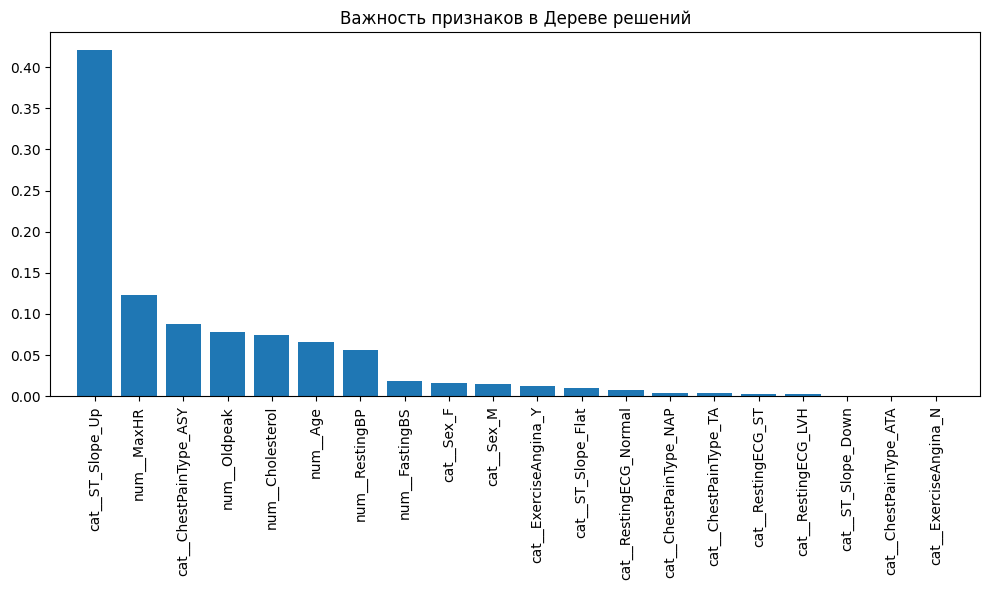

In [13]:
feature_names = pipeline_tree.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline_tree.named_steps['classifier'].feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Важность признаков в Дереве решений")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.xlim([-1, len(importances)])
plt.tight_layout()
plt.show()

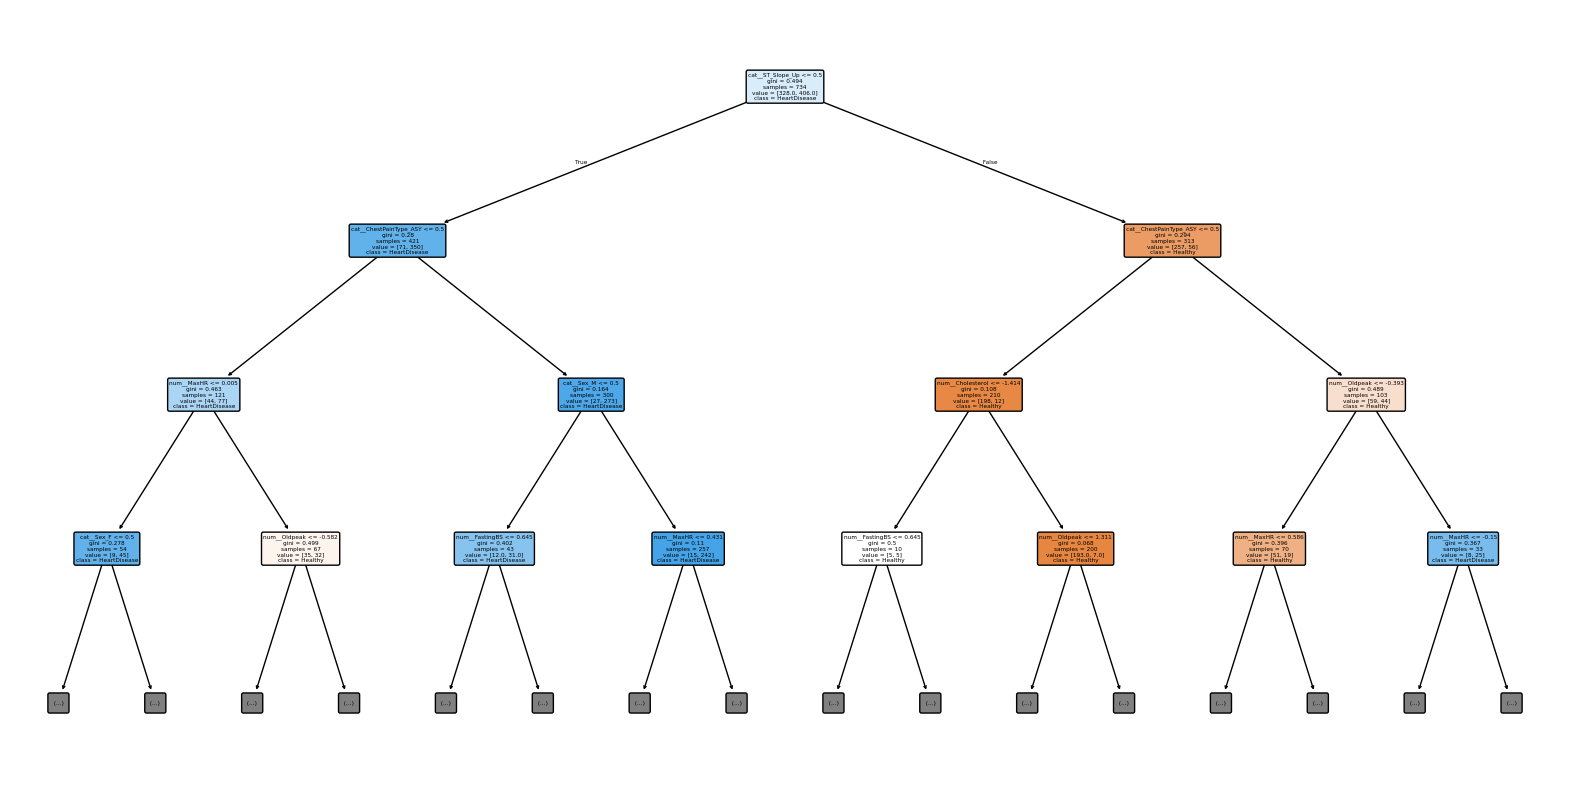

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    pipeline_tree.named_steps['classifier'],
    feature_names=feature_names,
    class_names=['Healthy', 'HeartDisease'],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()

In [25]:
param_grid_svm = {
    'classifier__C': [0.001, 0.1, 1, 10, 100],                         # Параметр регуляризации
    'classifier__kernel': ['linear', 'rbf', 'poly'],            # Тип ядра
    'classifier__gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001, 0.0001],   # Параметр gamma
}

grid_search_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=False
)

grid_search_svm.fit(X_train, y_train)

print(f"Best params: {grid_search_svm.best_params_}")
print(f"Best CV score: {grid_search_svm.best_score_:.4f}")
print(classification_report(y_test, y_pred))

Best params: {'classifier__C': 10, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}
Best CV score: 0.8776
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

